# Лекция 2. Ноутбук 2: Анализ тональности текста

Продолжение `notebook_1_about_neural.ipynb`. Там мы разобрали кирпичики нейросети на числах. Здесь применим те же идеи к тексту.

В этом ноутбуке:
1. Почему текст нужно сначала превратить в числа
2. Готовая модель оценивает тональность (без нашего обучения)
3. Поиск ближайших текстов по смыслу
4. Своя модель на `keras` (датасет `IMDB`)
5. Схема архитектуры текстовой сети


In [15]:
# Установка библиотек (выполнить один раз)
!pip install -q numpy pandas matplotlib seaborn scikit-learn tensorflow sentence-transformers transformers torch
# !uv pip install numpy pandas matplotlib seaborn scikit-learn tensorflow sentence-transformers transformers torch && uv sync


zsh:1: command not found: pip


In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import pipeline

np.random.seed(42)
random.seed(42)
keras.utils.set_random_seed(42)

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 140)


/Users/roman/Projects/semantic-vvsu-2026/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. От чисел к тексту

В первом ноутбуке на вход модели шли числа. Со строкой текста так не получится — нейросеть умеет работать только с числами.

Поэтому перед подачей текста в сеть нужен дополнительный шаг:

**Текст → числа → слои → ответ**

Всё остальное (слои, активации, loss, `fit()`, `predict()`) работает точно так же, как раньше.


In [2]:
# Загружаем тексты из train_data.txt

candidate_paths = [
    Path("./train_data.txt"),
]
DATA_PATH = next((path for path in candidate_paths if path.exists()), candidate_paths[-1])

texts = [line.strip() for line in DATA_PATH.read_text(encoding="utf-8").splitlines() if line.strip()]
df_texts = pd.DataFrame({
    "text_id": np.arange(len(texts)),
    "text": texts
})

display(df_texts)

print(f"Файл с текстами: {DATA_PATH}")
print(f"Количество текстов: {len(texts)}")
print("Этот файл можно редактировать и затем заново запускать ячейки с готовой моделью и поиском ближайших текстов.")


,text_id,text
0,0,Приложение работает быстро и очень удобно.
1,1,Интерфейс приложения понятный и логичный.
2,2,Приложение постоянно зависает и раздражает.
3,3,Фильм получился захватывающим и эмоциональным.
4,4,Этот фильм скучный и слишком затянутый.
5,5,"Доставка приехала вовремя, курьер был вежливым."
6,6,"Курьер опоздал на час, и заказ приехал холодным."
7,7,В ресторане вкусная еда и уютная атмосфера.
8,8,"В ресторане громко, еда холодная и обслуживание медленное."
9,9,"Ноутбук работает стабильно, а батарея держит долго."


Файл с текстами: train_data.txt
Количество текстов: 15
Этот файл можно редактировать и затем заново запускать ячейки с готовой моделью и поиском ближайших текстов.


## 2. Готовая модель: тональность без обучения

Берем модель, которую **кто-то уже обучил** за нас на большом корпусе русских текстов. Мы просто вызываем `predict` — веса уже внутри.

Это удобно, когда нужно быстро получить результат без сбора данных и без `fit()`.


Loading weights: 100%|█| 201/201 [00:00<00:00, 1746.0
BertForSequenceClassification LOAD REPORT from: seara/rubert-base-cased-russian-sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,text,raw_label,sentiment,score
0,Приложение работает быстро и очень удобно.,positive,позитивная,0.8535
1,Интерфейс приложения понятный и логичный.,positive,позитивная,0.7202
2,Приложение постоянно зависает и раздражает.,neutral,нейтральная,0.7496
3,Фильм получился захватывающим и эмоциональным.,positive,позитивная,0.9376
4,Этот фильм скучный и слишком затянутый.,neutral,нейтральная,0.7082
5,"Доставка приехала вовремя, курьер был вежливым.",positive,позитивная,0.9626
6,"Курьер опоздал на час, и заказ приехал холодным.",neutral,нейтральная,0.5322
7,В ресторане вкусная еда и уютная атмосфера.,positive,позитивная,0.9877
8,"В ресторане громко, еда холодная и обслуживание медленное.",neutral,нейтральная,0.8305
9,"Ноутбук работает стабильно, а батарея держит долго.",neutral,нейтральная,0.7356


/var/folders/_9/2d5wbxx93z15rd2x0lz3wdf40000gn/T/ipykernel_68090/2813808662.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sentiment, x="sentiment", order=order, palette="viridis")


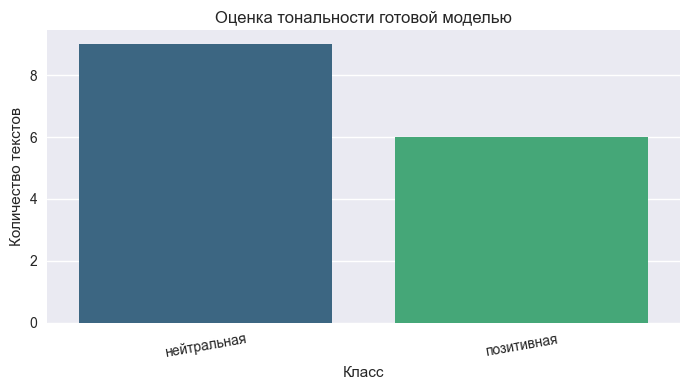

In [3]:
# Готовая модель для русскоязычной оценки тональности

sentiment_model_name = "seara/rubert-base-cased-russian-sentiment"
sentiment_pipe = pipeline(
    "text-classification",
    model=sentiment_model_name,
    tokenizer=sentiment_model_name
)

label_to_ru = {
    "positive": "позитивная",
    "negative": "негативная",
    "neutral": "нейтральная",
    "POSITIVE": "позитивная",
    "NEGATIVE": "негативная",
    "NEUTRAL": "нейтральная",
    "LABEL_0": "нейтральная",
    "LABEL_1": "позитивная",
    "LABEL_2": "негативная"
}

sentiment_results = sentiment_pipe(texts, truncation=True, max_length=256)
df_sentiment = pd.DataFrame({
    "text": texts,
    "raw_label": [item["label"] for item in sentiment_results],
    "sentiment": [label_to_ru.get(item["label"], item["label"]) for item in sentiment_results],
    "score": [round(float(item["score"]), 4) for item in sentiment_results]
})

display(df_sentiment)

plt.figure(figsize=(7, 4))
order = df_sentiment["sentiment"].value_counts().index
sns.countplot(data=df_sentiment, x="sentiment", order=order, palette="viridis")
plt.title("Оценка тональности готовой моделью")
plt.xlabel("Класс")
plt.ylabel("Количество текстов")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


## 3. Поиск ближайших текстов по смыслу

Тональность отвечает на вопрос **«какая эмоция?»**. А иногда нужно другое: **«какие тексты похожи по смыслу?»**

Идея простая:
1. Модель превращает каждый текст в вектор чисел (эмбеддинг).
2. Считаем `cosine similarity` между векторами.
3. Чем выше число, тем ближе тексты по смыслу.

Это та же векторизация, что в первой лекции, только вектор создает нейросеть, а не `TF-IDF`.


Loading weights: 100%|█| 199/199 [00:00<00:00, 1892.8
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


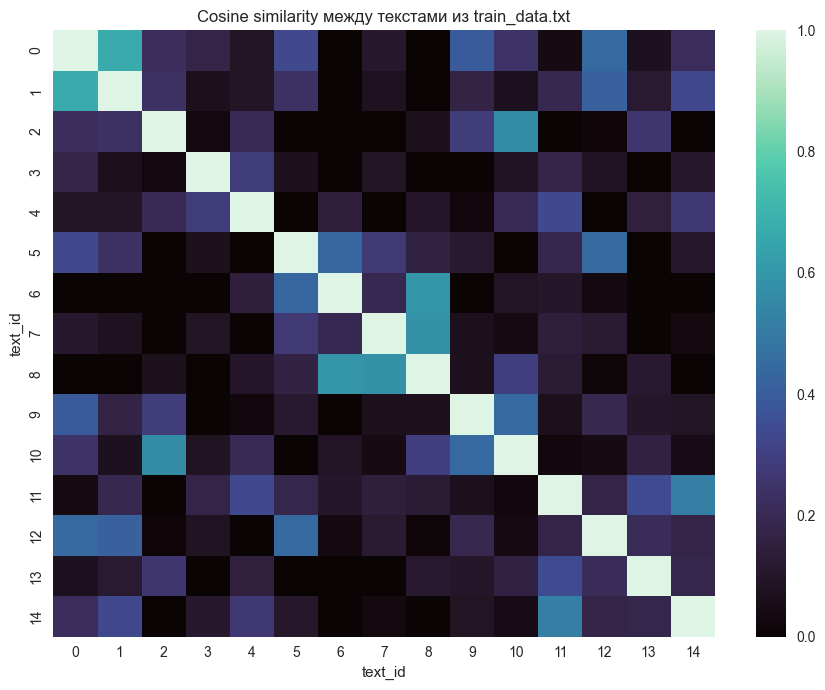

Запрос: Приложение удобное, быстро работает и не вызывает раздражения.


,rank,text_id,similarity,text
0,1,0,0.9073,Приложение работает быстро и очень удобно.
1,2,1,0.6565,Интерфейс приложения понятный и логичный.
2,3,12,0.4439,Сервис оказался надежным и помог решить проблему с первого раза.


In [4]:
# Ищем ближайшие тексты через SentenceTransformer

semantic_model_name = "paraphrase-multilingual-MiniLM-L12-v2"
semantic_model = SentenceTransformer(semantic_model_name)

embeddings = semantic_model.encode(texts, normalize_embeddings=True)
sim_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(9, 7))
sns.heatmap(sim_matrix, cmap="mako", vmin=0, vmax=1)
plt.title("Cosine similarity между текстами из train_data.txt")
plt.xlabel("text_id")
plt.ylabel("text_id")
plt.tight_layout()
plt.show()

query_text = "Приложение удобное, быстро работает и не вызывает раздражения."
query_embedding = semantic_model.encode([query_text], normalize_embeddings=True)
query_scores = cosine_similarity(query_embedding, embeddings)[0]
top_k = 3
top_indices = np.argsort(query_scores)[::-1][:top_k]

nearest_df = pd.DataFrame({
    "rank": np.arange(1, top_k + 1),
    "text_id": top_indices,
    "similarity": np.round(query_scores[top_indices], 4),
    "text": [texts[idx] for idx in top_indices]
})

print(f"Запрос: {query_text}")
display(nearest_df)


## 4. Своя модель на `keras`: датасет IMDB

Теперь обучим сеть сами. Данные размечать не нужно — берем готовый датасет `IMDB` (отзывы на фильмы: `0` = негатив, `1` = позитив).

Архитектура та же, что в первом ноутбуке, но с двумя новыми блоками:

| Блок | Зачем |
|---|---|
| `Embedding` | Переводит индекс слова в плотный вектор (как Word2Vec, только обучается вместе с сетью) |
| `GlobalAveragePooling1D` | Усредняет векторы всех слов в один вектор текста |

Дальше — обычные `Dense`, `Dropout`, `sigmoid`, `binary_crossentropy`, `fit()`, `predict()`.


,label,decoded_review
0,1,<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you coul...
1,0,<START> big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love cheesy horro...
2,0,<START> this has to be one of the worst films of the 1990s when my friends i were watching this film being the target audience it was ai...


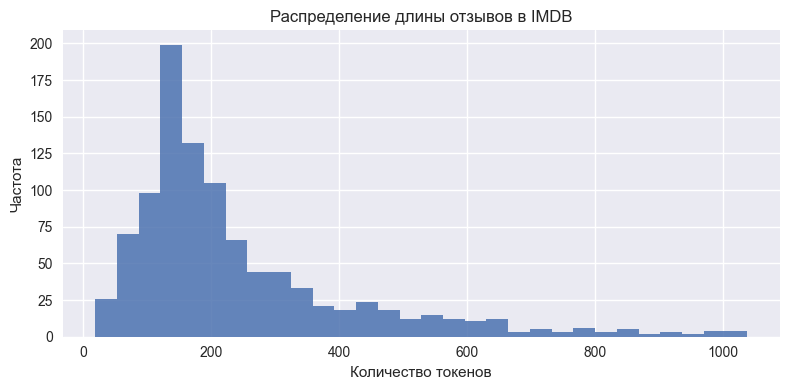

Размер train после ограничения: (12000, 200)
Размер test после ограничения: (5000, 200)
Используем подмножество датасета, чтобы ноутбук обучался быстрее на лекции.


In [5]:
# Загружаем готовый размеченный датасет IMDB

vocab_size = 20000
maxlen = 200
train_limit = 12000
test_limit = 5000

(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = keras.datasets.imdb.load_data(num_words=vocab_size)
word_index = keras.datasets.imdb.get_word_index()
reverse_word_index = {index + 3: word for word, index in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(sequence):
    return " ".join(reverse_word_index.get(token, "?") for token in sequence)

x_train = pad_sequences(x_train_raw[:train_limit], maxlen=maxlen, padding="post", truncating="post")
y_train = y_train_raw[:train_limit]
x_test = pad_sequences(x_test_raw[:test_limit], maxlen=maxlen, padding="post", truncating="post")
y_test = y_test_raw[:test_limit]

sample_reviews_df = pd.DataFrame({
    "label": y_train[:3],
    "decoded_review": [decode_review(seq[:80]) for seq in x_train_raw[:3]]
})

display(sample_reviews_df)

plt.figure(figsize=(8, 4))
review_lengths = [len(seq) for seq in x_train_raw[:1000]]
plt.hist(review_lengths, bins=30, color="#4C72B0", alpha=0.85)
plt.title("Распределение длины отзывов в IMDB")
plt.xlabel("Количество токенов")
plt.ylabel("Частота")
plt.tight_layout()
plt.show()

print(f"Размер train после ограничения: {x_train.shape}")
print(f"Размер test после ограничения: {x_test.shape}")
print("Используем подмножество датасета, чтобы ноутбук обучался быстрее на лекции.")


In [6]:
sample_reviews_df.to_numpy()

array([[1,
        "<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as"],
       [0,
        "<START> big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love cheesy horror movies and i've seen hundreds but this had got to be on of the worst ever made the plot is paper thin and ridiculous the acting is an abomination the script is completely laughable the best is the end showdown with the cop and how he worked out who the killer is it's just"],
       [0,
        '<START> this has to be one of the worst films of the 1990s when my fr

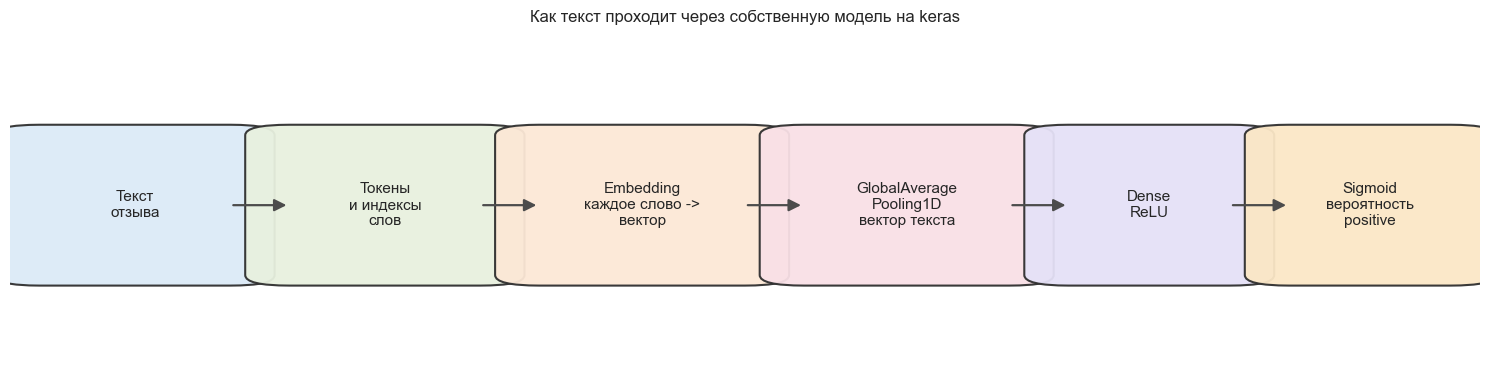

In [7]:
# Визуализируем архитектуру текстовой сети

def draw_box(ax, xy, width, height, text, color):
    box = FancyBboxPatch(
        xy,
        width,
        height,
        boxstyle="round,pad=0.03",
        linewidth=1.5,
        edgecolor="#2F2F2F",
        facecolor=color,
        alpha=0.95
    )
    ax.add_patch(box)
    ax.text(
        xy[0] + width / 2,
        xy[1] + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=11,
        wrap=True
    )

fig, ax = plt.subplots(figsize=(15, 4))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

boxes = [
    ((0.02, 0.3), 0.13, 0.4, "Текст\nотзыва", "#DCEAF7"),
    ((0.19, 0.3), 0.13, 0.4, "Токены\nи индексы\nслов", "#E8F1DF"),
    ((0.36, 0.3), 0.14, 0.4, "Embedding\nкаждое слово ->\nвектор", "#FCE8D6"),
    ((0.54, 0.3), 0.14, 0.4, "GlobalAverage\nPooling1D\nвектор текста", "#F9E0E6"),
    ((0.72, 0.3), 0.11, 0.4, "Dense\nReLU", "#E5E1F7"),
    ((0.87, 0.3), 0.11, 0.4, "Sigmoid\nвероятность\npositive", "#FBE7C6")
]

for xy, width, height, text, color in boxes:
    draw_box(ax, xy, width, height, text, color)

for start_x, end_x in [(0.15, 0.19), (0.32, 0.36), (0.50, 0.54), (0.68, 0.72), (0.83, 0.87)]:
    arrow = FancyArrowPatch(
        (start_x, 0.5),
        (end_x, 0.5),
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=1.6,
        color="#4C4C4C"
    )
    ax.add_patch(arrow)

plt.title("Как текст проходит через собственную модель на keras")
plt.tight_layout()
plt.show()


Структура модели:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 32)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling                         │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_dense (Dense)            │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,923,269 (7.34 MB)

 Trainable params: 641,089 (2.45 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,282,180 (4.89 MB)


Test loss: 0.4025
Test accuracy: 0.8380


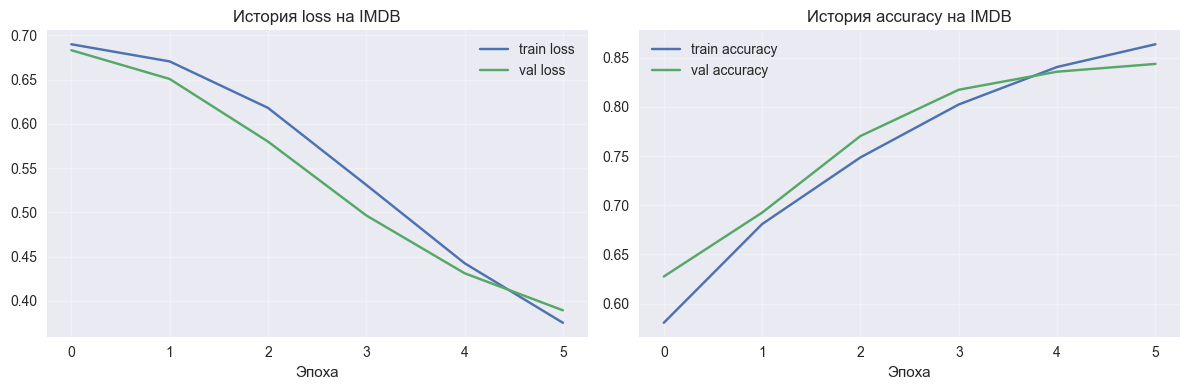

In [8]:
# Создаем и обучаем собственную модель

imdb_model = keras.Sequential([
    layers.Input(shape=(maxlen,)),
    layers.Embedding(input_dim=vocab_size, output_dim=32, name="embedding"),
    layers.GlobalAveragePooling1D(name="pooling"),
    layers.Dense(32, activation="relu", name="hidden_dense"),
    layers.Dropout(0.3, name="dropout"),
    layers.Dense(1, activation="sigmoid", name="output")
])

imdb_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = imdb_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=6,
    batch_size=256,
    verbose=0
)

test_loss, test_accuracy = imdb_model.evaluate(x_test, y_test, verbose=0)

print("Структура модели:")
imdb_model.summary()
print(f"\nTest loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("История loss на IMDB")
axes[0].set_xlabel("Эпоха")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["accuracy"], label="train accuracy")
axes[1].plot(history.history["val_accuracy"], label="val accuracy")
axes[1].set_title("История accuracy на IMDB")
axes[1].set_xlabel("Эпоха")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


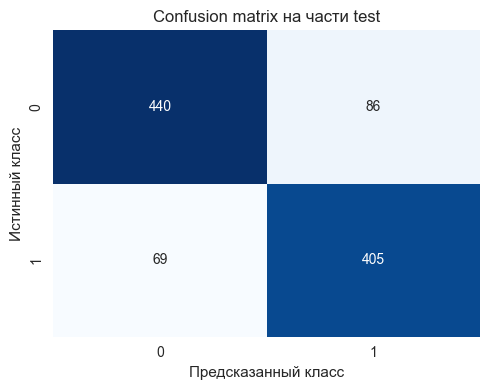

              precision    recall  f1-score   support

    negative       0.86      0.84      0.85       526
    positive       0.82      0.85      0.84       474

    accuracy                           0.84      1000
   macro avg       0.84      0.85      0.84      1000
weighted avg       0.85      0.84      0.85      1000



,true_label,predicted_label,predicted_probability_positive,decoded_review_fragment
0,negative,negative,0.4447,<START> please give this one a miss br br kristy swanson and the rest of the cast rendered terrible performances the show is flat flat f...
1,positive,positive,0.9664,<START> this film requires a lot of patience because it focuses on mood and character development the plot is very simple and many of th...
2,positive,positive,0.7700,<START> many animation buffs consider <UNK> <UNK> the great forgotten genius of one special branch of the art puppet animation which he ...


Здесь снова работает та же логика из первого ноутбука:
1. На вход приходит числовое представление текста.
2. Скрытые слои выделяют полезные признаки.
3. Sigmoid возвращает вероятность положительного класса.
4. Затем вероятность превращается в класс по порогу 0.5.


In [9]:
# Смотрим, как модель предсказывает тональность

sample_count = 1000
sample_probs = imdb_model.predict(x_test[:sample_count], verbose=0).flatten()
sample_preds = (sample_probs >= 0.5).astype(int)
cm = confusion_matrix(y_test[:sample_count], sample_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion matrix на части test")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.tight_layout()
plt.show()

print(classification_report(y_test[:sample_count], sample_preds, target_names=["negative", "positive"]))

example_indices = [0, 1, 2]
examples_df = pd.DataFrame({
    "true_label": ["positive" if y_test[i] == 1 else "negative" for i in example_indices],
    "predicted_label": ["positive" if sample_probs[i] >= 0.5 else "negative" for i in example_indices],
    "predicted_probability_positive": [round(float(sample_probs[i]), 4) for i in example_indices],
    "decoded_review_fragment": [decode_review(x_test_raw[i][:80]) for i in example_indices]
})

display(examples_df)

print("Здесь снова работает та же логика из первого ноутбука:")
print("1. На вход приходит числовое представление текста.")
print("2. Скрытые слои выделяют полезные признаки.")
print("3. Sigmoid возвращает вероятность положительного класса.")
print("4. Затем вероятность превращается в класс по порогу 0.5.")


## Итог

| Что узнали | Коротко |
|---|---|
| Текст нельзя подать в сеть напрямую | Сначала превращаем в числа (токены, эмбеддинги) |
| Готовые модели | Быстрая оценка тональности без `fit()` |
| Эмбеддинги + cosine similarity | Поиск похожих текстов |
| `Embedding` + `Pooling` | Специальные слои для текста |
| Всё остальное | Те же `Dense`, `loss`, `fit()`, `predict()` |

Нейросети для текста — те же кирпичики из первого ноутбука + этап перевода слов в числа.
